# Abhishek Kothari
# Assignment 5 A

### Problem 1

In [2]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
import pandas as pd
import numpy as np

In [3]:
# Load 20 NewsGroups dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
docs_20ng = newsgroups.data

In [5]:
# Vectorize the dataset
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X_20ng = vectorizer.fit_transform(docs_20ng)


In [6]:
from datasets import load_dataset

duc_ds = load_dataset("midas/duc2001", "raw")

In [16]:
duc_ds['test']['document'][0]

['Here',
 ',',
 'at',
 'a',
 'glance',
 ',',
 'are',
 'developments',
 'today',
 'involving',
 'the',
 'crash',
 'of',
 'Pan',
 'American',
 'World',
 'Airways',
 'Flight',
 '103',
 'Wednesday',
 'night',
 'in',
 'Lockerbie',
 ',',
 'Scotland',
 ',',
 'that',
 'killed',
 'all',
 '259',
 'people',
 'aboard',
 'and',
 'more',
 'than',
 '20',
 'people',
 'on',
 'the',
 'ground',
 ':']

In [10]:
docs_duc = [item['document'] if isinstance(item['document'], str) else " ".join(item['document']) for item in duc_ds['test']]

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_duc = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X_duc = vectorizer_duc.fit_transform(docs_duc)

In [30]:
from sklearn.decomposition import LatentDirichletAllocation, NMF

# Function to print top words per topic
def print_top_words_with_probs(model, feature_names, n_top_words=20):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx + 1}:")
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words_probs = topic[top_words_idx] / topic.sum()  # Normalize to get probabilities
        for word, prob in zip([feature_names[i] for i in top_words_idx], top_words_probs):
            print(f"{word}: {prob:.4f}")
        print("\n")

In [24]:
# Define number of topics
topics_list = [10, 20, 50]

# Get feature names
feature_names = vectorizer_duc.get_feature_names_out()

In [34]:
# Loop over K values and run both LDA and NMF
for k in topics_list:
    print(f"=== LDA with {k} topics ===")
    lda_model = LatentDirichletAllocation(n_components=k, random_state=42)
    lda_model.fit(X_duc)
    print_top_words_with_probs(lda_model, feature_names)

    print(f"=== NMF with {k} topics ===")
    nmf_model = NMF(n_components=k, random_state=42)
    nmf_model.fit(X_duc)
    print_top_words_with_probs(nmf_model, feature_names)

=== LDA with 10 topics ===
Topic #1:
slovenia: 0.0158
gun: 0.0109
said: 0.0082
yugoslavia: 0.0078
right: 0.0065
mr: 0.0063
state: 0.0061
federal: 0.0053
arms: 0.0051
control: 0.0048
government: 0.0048
amendment: 0.0047
guns: 0.0044
people: 0.0044
slovene: 0.0043
militia: 0.0043
second: 0.0043
croatia: 0.0040
assassination: 0.0039
republic: 0.0039


Topic #2:
said: 0.0150
police: 0.0110
year: 0.0084
diamond: 0.0064
city: 0.0052
beers: 0.0050
marathon: 0.0049
race: 0.0046
people: 0.0046
diamonds: 0.0044
time: 0.0040
officers: 0.0039
lrb: 0.0038
rrb: 0.0038
says: 0.0036
world: 0.0033
south: 0.0032
miles: 0.0032
new: 0.0032
000: 0.0031


Topic #3:
said: 0.0204
diabetes: 0.0130
taylor: 0.0101
jackson: 0.0089
police: 0.0053
doctors: 0.0052
hospital: 0.0051
pneumonia: 0.0049
health: 0.0047
dickey: 0.0046
disease: 0.0042
miss: 0.0041
long: 0.0039
al: 0.0038
officer: 0.0038
people: 0.0037
group: 0.0037
beach: 0.0035
report: 0.0033
car: 0.0032


Topic #4:
term: 0.0152
shining: 0.0147
path: 0.014

In [46]:
for K in [10, 20, 50]:
    print(f"\n=== LDA with K={K} ===")
    lda = LatentDirichletAllocation(n_components=K, random_state=42)
    lda.fit(X_20ng)
    print_top_words_with_probs(lda, vectorizer.get_feature_names_out())
    
    print(f"\n=== NMF with K={K} ===")
    tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
    X_20ng_tfidf = tfidf_vectorizer.fit_transform(docs_20ng)
    
    nmf = NMF(n_components=K, random_state=42)
    nmf.fit(X_20ng_tfidf)
    print_top_words_with_probs(nmf, tfidf_vectorizer.get_feature_names_out())


=== LDA with K=10 ===
Topic #1:
space: 0.0102
00: 0.0066
armenian: 0.0059
turkish: 0.0052
new: 0.0047
earth: 0.0042
armenians: 0.0035
nasa: 0.0030
50: 0.0030
10: 0.0029
turkey: 0.0029
university: 0.0027
years: 0.0025
orbit: 0.0025
greek: 0.0025
book: 0.0024
moon: 0.0024
shuttle: 0.0023
genocide: 0.0023
000: 0.0023


Topic #2:
use: 0.0069
windows: 0.0069
file: 0.0055
dos: 0.0049
drive: 0.0047
image: 0.0043
using: 0.0041
does: 0.0041
like: 0.0040
software: 0.0039
program: 0.0038
version: 0.0037
problem: 0.0036
know: 0.0035
bit: 0.0034
card: 0.0034
files: 0.0034
disk: 0.0033
available: 0.0032
window: 0.0032


Topic #3:
file: 0.0056
use: 0.0047
health: 0.0042
medical: 0.0040
number: 0.0035
program: 0.0035
entry: 0.0032
disease: 0.0032
research: 0.0031
study: 0.0030
1993: 0.0030
cancer: 0.0027
patients: 0.0027
information: 0.0027
drug: 0.0027
output: 0.0027
new: 0.0024
gun: 0.0024
used: 0.0022
year: 0.0021


Topic #4:
israel: 0.0058
jews: 0.0052
war: 0.0040
people: 0.0038
jewish: 0.0034
is

/Users/DELL/anaconda3/anaconda3/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [50]:
# Fit LDA for K=20 and K=50
lda_20 = LatentDirichletAllocation(n_components=20, random_state=42)
lda_50 = LatentDirichletAllocation(n_components=50, random_state=42)

X_topics_20 = lda_20.fit_transform(X_20ng)
X_topics_50 = lda_50.fit_transform(X_20ng)

In [51]:
# Get 20NG target labels
labels = newsgroups.target
label_names = newsgroups.target_names

# Function to find dominant topic for each document
def get_dominant_topics(topic_matrix):
    return np.argmax(topic_matrix, axis=1)

In [52]:
# Get dominant topics per doc for K=20 and K=50
dominant_topics_20 = get_dominant_topics(X_topics_20)
dominant_topics_50 = get_dominant_topics(X_topics_50)


In [56]:
# Create DataFrame for visualization
df_20 = pd.DataFrame({'Topic': dominant_topics_20, 'Label': labels})
df_50 = pd.DataFrame({'Topic': dominant_topics_50, 'Label': labels})

# Count topics per class
topic_label_count_20 = pd.crosstab(df_20['Label'], df_20['Topic'])
topic_label_count_50 = pd.crosstab(df_50['Label'], df_50['Topic'])

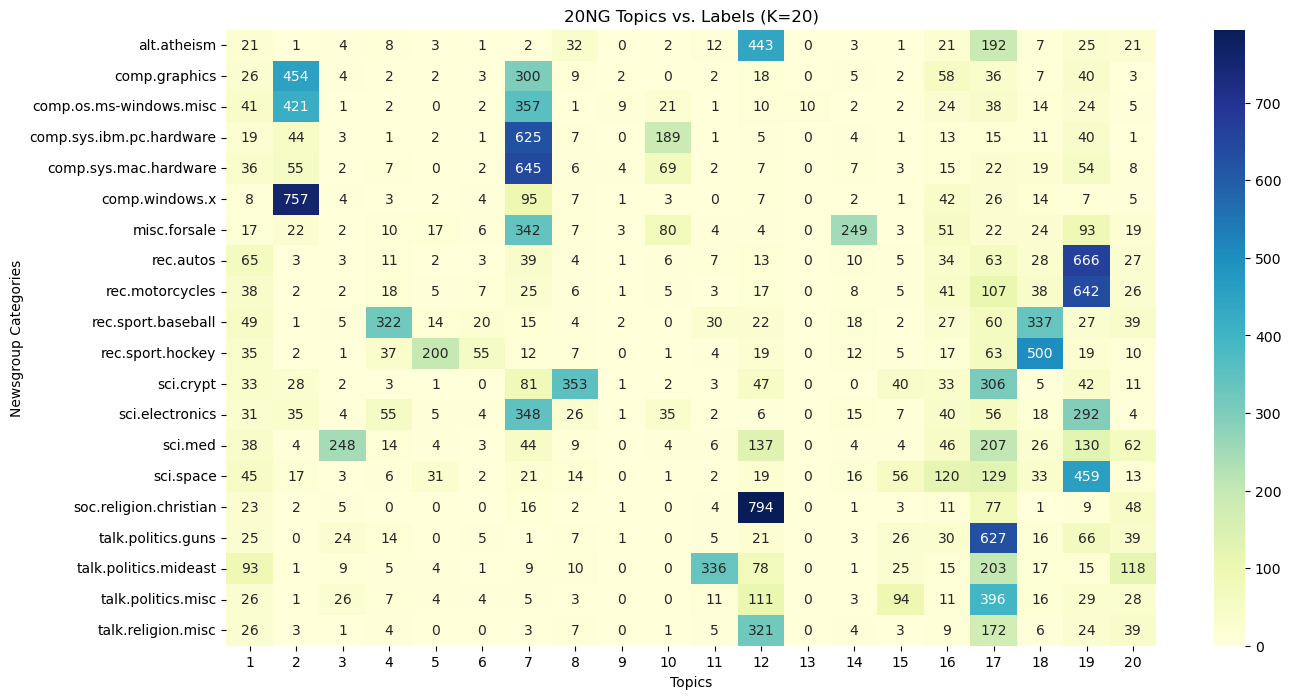

In [58]:
# Plot heatmap to visualize alignment for K=20
plt.figure(figsize=(15, 8))
sns.heatmap(topic_label_count_20, cmap="YlGnBu", annot=True, fmt="d", xticklabels=range(1, 21), yticklabels=label_names)
plt.title("20NG Topics vs. Labels (K=20)")
plt.xlabel("Topics")
plt.ylabel("Newsgroup Categories")
plt.show()

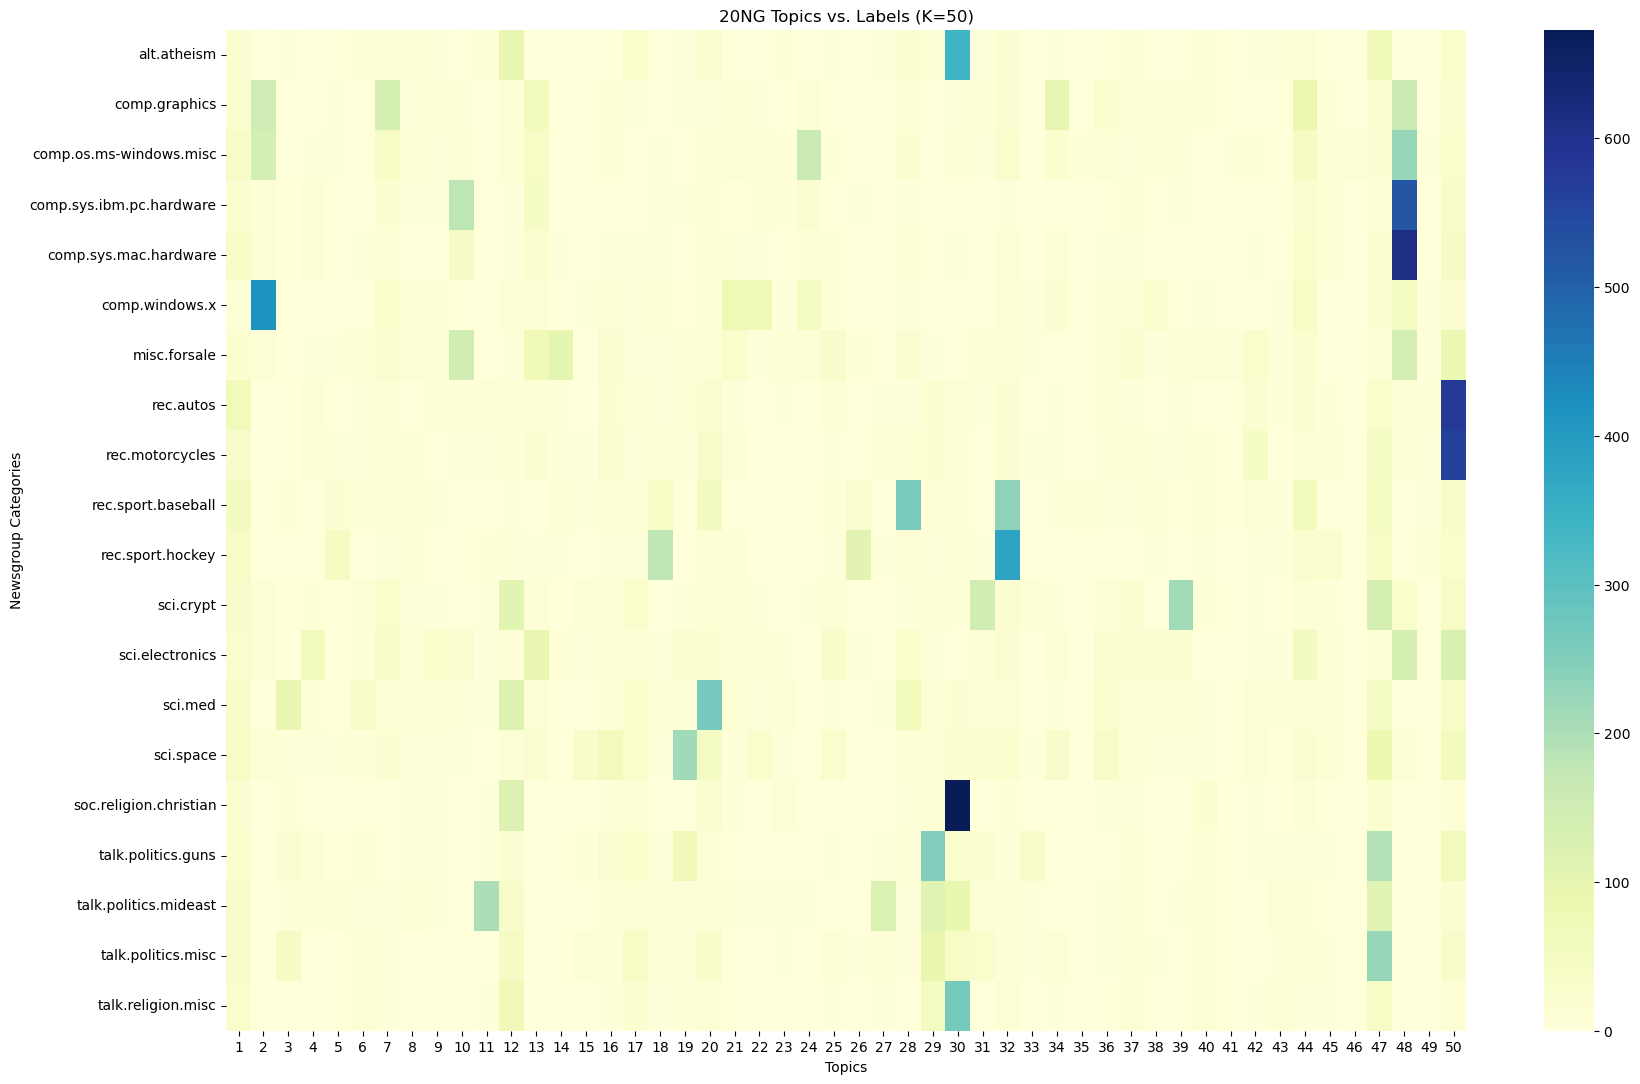

In [62]:
# Plot heatmap to visualize alignment for K=50
plt.figure(figsize=(20, 13))
sns.heatmap(topic_label_count_50, cmap="YlGnBu", annot=False, fmt="d", xticklabels=range(1, 51), yticklabels=label_names)
plt.title("20NG Topics vs. Labels (K=50)")
plt.xlabel("Topics")
plt.ylabel("Newsgroup Categories")
plt.show()

From the two diagrams, we can observe that with K=50, the topics are more granular and spaced out compared to K=20. However, the overall structure and pattern remain consistent between both configurations.

### Question 2

In [135]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from rouge import Rouge
import numpy as np
import os
import re
from datasets import load_dataset
from sklearn.datasets import fetch_20newsgroups

nltk.download('punkt')
nltk.download('stopwords')

def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text).lower()
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

def kl_sum(sentences, document_tokens, num_sentences, use_topics=False, lda=None, vectorizer=None):
    summary = []
    summary_tokens = []
    remaining_sentences = sentences[:]

    if use_topics and lda is None:
        raise ValueError("LDA model must be provided when using topics.")

    def calculate_kl_divergence(p, q):
        p = np.array(p) + 1e-10
        q = np.array(q) + 1e-10
        return np.sum(p * np.log(p / q))

    def get_distribution(tokens, all_tokens=None, lda_model=None, vectorizer=None):
        if use_topics and lda_model:
            doc_term_matrix = vectorizer.transform([" ".join(tokens)])
            topic_distribution = lda_model.transform(doc_term_matrix)[0]
            return topic_distribution
        else:
            if all_tokens is None:
                all_tokens = document_tokens
            counts = {}
            for token in tokens:
                counts[token] = counts.get(token, 0) + 1
            distribution = [counts.get(token, 0) / len(all_tokens) for token in all_tokens]
            return distribution

    document_distribution = get_distribution(document_tokens, lda_model=lda, vectorizer=vectorizer)

    while len(summary) < num_sentences and remaining_sentences:
        kl_divergences = []
        for sentence in remaining_sentences:
            sentence_tokens = preprocess_text(sentence)
            new_summary_tokens = summary_tokens + sentence_tokens
            summary_distribution = get_distribution(new_summary_tokens, document_tokens, lda_model=lda, vectorizer=vectorizer)
            kl_divergence = calculate_kl_divergence(summary_distribution, document_distribution)
            kl_divergences.append(kl_divergence)

        best_sentence_index = np.argmin(kl_divergences)
        best_sentence = remaining_sentences.pop(best_sentence_index)
        summary.append(best_sentence)
        summary_tokens += preprocess_text(best_sentence)

    return summary

def evaluate_rouge(summary, gold_summary):
    rouge = Rouge()
    scores = rouge.get_scores(" ".join(summary), gold_summary)[0]
    return scores

def extract_base_filename(filename):
    return os.path.splitext(filename)[0]

def process_duc_dataset(documents, gold_summary_dir, num_sentences, use_topics=False):
    all_rouge_scores = []
    all_summaries = []
    all_gold_summaries = []

    lda_model = None
    vectorizer = None

    if use_topics:
        all_documents_tokens = []
        for doc_list in documents:
            full_doc_string = " ".join(doc_list)
            tokens = [token for sentence in sent_tokenize(full_doc_string) for token in preprocess_text(sentence)]
            all_documents_tokens.append(" ".join(tokens))

        vectorizer = CountVectorizer()
        doc_term_matrix = vectorizer.fit_transform(all_documents_tokens)
        lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
        lda_model.fit(doc_term_matrix)

    for i, doc_list in enumerate(documents):
        full_doc_string = " ".join(doc_list)
        sentences = sent_tokenize(full_doc_string)
        document_tokens = [token for sentence in sentences for token in preprocess_text(sentence)]

        summary = kl_sum(sentences, document_tokens, num_sentences, use_topics, lda_model, vectorizer)
        all_summaries.append(" ".join(summary))

        prefix = "ap"
        if i == 0: prefix = "ap"
        elif i == 1: prefix = "fbis"
        elif i == 2: prefix = "ft"
        elif i == 3: prefix = "la"
        elif i == 4: prefix = "sjmn"
        elif i == 5: prefix = "wsj"

        gold_summary_filename = None
        for filename in os.listdir(gold_summary_dir):
            if filename.startswith(prefix):
                gold_summary_filename = filename
                break

        if gold_summary_filename:
            gold_summary_path = os.path.join(gold_summary_dir, gold_summary_filename)
            try:
                with open(gold_summary_path, 'r', encoding='utf-8') as gold_file:
                    gold_summary = gold_file.read().strip()
                    all_gold_summaries.append(gold_summary)
                    rouge_scores = evaluate_rouge(summary, gold_summary)
                    all_rouge_scores.append(rouge_scores)
            except FileNotFoundError:
                all_gold_summaries.append("")
                all_rouge_scores.append(None)
        else:
            all_gold_summaries.append("")
            all_rouge_scores.append(None)

    all_rouge_scores = [score for score in all_rouge_scores if score is not None]

    if all_rouge_scores:
        avg_rouge_1 = np.mean([score['rouge-1']['f'] for score in all_rouge_scores])
        avg_rouge_2 = np.mean([score['rouge-2']['f'] for score in all_rouge_scores])
        avg_rouge_l = np.mean([score['rouge-l']['f'] for score in all_rouge_scores])
    else:
        avg_rouge_1, avg_rouge_2, avg_rouge_l = 0, 0, 0

    return avg_rouge_1, avg_rouge_2, avg_rouge_l

def process_20ng_dataset(documents, num_sentences, use_topics=False):
    all_summaries = []

    lda_model = None
    vectorizer = None

    if use_topics:
        all_documents_tokens = []
        for doc in documents:
            tokens = [token for sentence in sent_tokenize(doc) for token in preprocess_text(sentence)]
            all_documents_tokens.append(" ".join(tokens))
        vectorizer = CountVectorizer()
        doc_term_matrix = vectorizer.fit_transform(all_documents_tokens)
        lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
        lda_model.fit(doc_term_matrix)

    for doc in documents:
        sentences = sent_tokenize(doc)
        document_tokens = [token for sentence in sentences for token in preprocess_text(sentence)]
        summary = kl_sum(sentences, document_tokens, num_sentences, use_topics, lda_model, vectorizer)
        all_summaries.append(" ".join(summary))

    return all_summaries


[nltk_data] Downloading package punkt to /Users/DELL/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/DELL/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [137]:
ds = load_dataset("midas/duc2001", "raw")
docs_duc = ds['test']['document']
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
docs_20ng = newsgroups.data

duc_gold_summary_dir = "Summaries"
num_sentences = 5

avg_rouge_1_duc, avg_rouge_2_duc, avg_rouge_l_duc = process_duc_dataset(docs_duc, duc_gold_summary_dir, num_sentences, use_topics=False)
print("\nDUC 2000 ROUGE scores (words):")
print(f"ROUGE-1: {avg_rouge_1_duc}")
print(f"ROUGE-2: {avg_rouge_2_duc}")
print(f"ROUGE-L: {avg_rouge_l_duc}")

avg_rouge_1_duc_topics, avg_rouge_2_duc_topics, avg_rouge_l_duc_topics = process_duc_dataset(docs_duc, duc_gold_summary_dir, num_sentences, use_topics=True)
print("\nDUC 2000 ROUGE scores (topics):")
print(f"ROUGE-1: {avg_rouge_1_duc_topics}")
print(f"ROUGE-2: {avg_rouge_2_duc_topics}")
print(f"ROUGE-L: {avg_rouge_l_duc_topics}")

process_20ng_dataset(docs_20ng, num_sentences, use_topics=False)
process_20ng_dataset(docs_20ng, num_sentences, use_topics=True)


DUC 2000 ROUGE scores (words):
ROUGE-1: 0.11687618968543587
ROUGE-2: 0.018049981311472226
ROUGE-L: 0.10938732648796716

DUC 2000 ROUGE scores (topics):
ROUGE-1: 0.11887596911180094
ROUGE-2: 0.01881406424038014
ROUGE-L: 0.1097006492375866


["Bowman should let JAgr have a lot of\nfun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. \n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pens massacre of the Devils. However, I am going to put an end\nto non-PIttsburghers' relief with a bit of praise for the Pens. I was very disappointed not to see the Islanders lose the final\nregular season game. He is also a lot\nfo fun to watch in the playoffs.",
 'Does anyone have suggestions/ideas on:\n\n  - Diamond Stealth Pro Local Bus\n\n  - Orchid Farenheit 1280\n\n  - ATI Graphics Ultra Pro\n\n  - Any other high-performance VLB card\n\n\nPlease post or email. My brother is in the market for a high-performance video card that supports\nVESA local bus with 1-2MB RAM. Thank you! - Matt',
 'Ohhh i forgot, this is how Armenians fight, nobody has forgot\n\tyou killings, rapings and torture against the Kurds and Turks once\n\tupon a time